# 04 — Buy-and-hold backtest (vectorbt)

10-year buy-and-hold of the 4-ETF portfolio selected in notebook 03 (25% equal-weight, top SSR per category: world/sector/commodity/bond). Benchmarked against SPY B&H.

> **In-sample.** The portfolio was chosen using SSR computed over the same 2016–2026 window we now simulate — this is a hindsight test of the construction method, not an out-of-sample result. Walk-forward next.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd

import macro_framework as mf

pd.set_option("display.width", 180)

## 1. Load portfolio + price history

In [3]:
START = "2016-01-31"
END = "2026-01-31"
INIT_CASH = 100_000.0
BENCHMARK = "SPY"

portfolio_spec = pd.read_parquet(Path.cwd().parent / "data" / "portfolio_ssr_top_per_category.parquet")
symbols = portfolio_spec["symbol"].tolist()
weights = dict(zip(portfolio_spec["symbol"], portfolio_spec["weight"]))

prices = mf.get_prices(symbols + [BENCHMARK], start=START, end=END)
portfolio_spec[["symbol", "name", "category", "score", "weight"]]

,symbol,name,category,score,weight
0,SWDA.L,iShares Core MSCI World UCITS ETF,world,100.000000,0.25
1,XLK,Technology Select Sector SPDR Fund,sector,99.056604,0.25
2,IAU,iShares Gold Trust,commodity,63.207547,0.25
3,BIL,SPDR Bloomberg 1-3 Month T-Bill ETF,bond,21.698113,0.25


## 2. Run backtests

In [4]:
pf = mf.buy_and_hold(prices[symbols], weights, init_cash=INIT_CASH)
bench = mf.single_asset_buy_and_hold(prices[BENCHMARK], init_cash=INIT_CASH)

stats = mf.summary(pf, bench, label="SSR-EW-4", benchmark_label=f"{BENCHMARK} B&H")
stats.round(4)

,SSR-EW-4,SPY B&H
total_return,2.9371,2.5733
annualized_return,0.2247,0.2030
annualized_volatility,0.1479,0.2163
sharpe_ratio,1.4446,0.9633
sortino_ratio,2.0635,1.3526
calmar_ratio,1.1532,0.5952
max_drawdown,-0.1948,-0.3410


## 3. Per-ETF contributions (standalone B&H stats for each leg)

In [5]:
legs = {}
for sym in symbols:
    leg_pf = mf.single_asset_buy_and_hold(prices[sym], init_cash=INIT_CASH)
    legs[sym] = {
        "total_return": float(leg_pf.total_return()),
        "annualized_return": float(leg_pf.annualized_return()),
        "annualized_vol": float(leg_pf.annualized_volatility()),
        "sharpe": float(leg_pf.sharpe_ratio()),
        "max_drawdown": float(leg_pf.max_drawdown()),
    }
legs_df = pd.DataFrame(legs).T.round(4)
legs_df.merge(portfolio_spec[["symbol", "category", "score"]].set_index("symbol"), left_index=True, right_index=True)

,total_return,annualized_return,annualized_vol,sharpe,max_drawdown,category,score
SWDA.L,2.6145,0.2068,0.1771,1.1505,-0.2558,world,100.000000
XLK,5.9507,0.3250,0.2910,1.1129,-0.3402,sector,99.056604
IAU,3.1797,0.2307,0.1838,1.2219,-0.2182,commodity,63.207547
BIL,0.0034,0.0005,0.0098,0.0552,-0.0070,bond,21.698113


## 4. Equity curve & drawdown

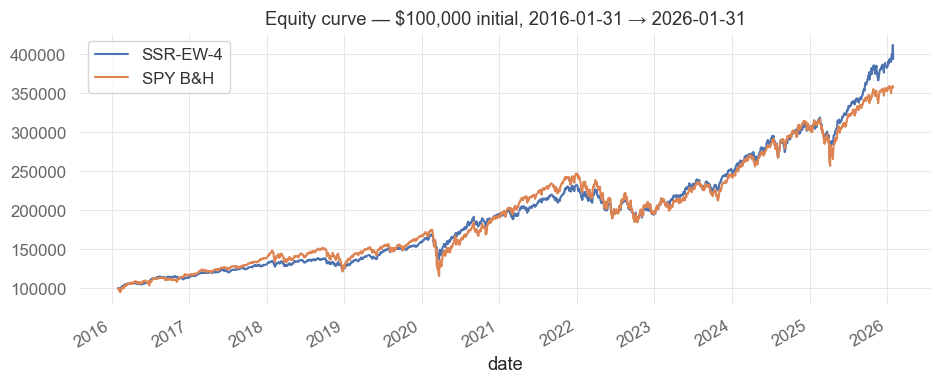

In [6]:
equity = pd.DataFrame({
    "SSR-EW-4": pf.value(),
    f"{BENCHMARK} B&H": bench.value(),
})
equity.plot(figsize=(11, 4), title=f"Equity curve — ${INIT_CASH:,.0f} initial, {START} → {END}", grid=True);

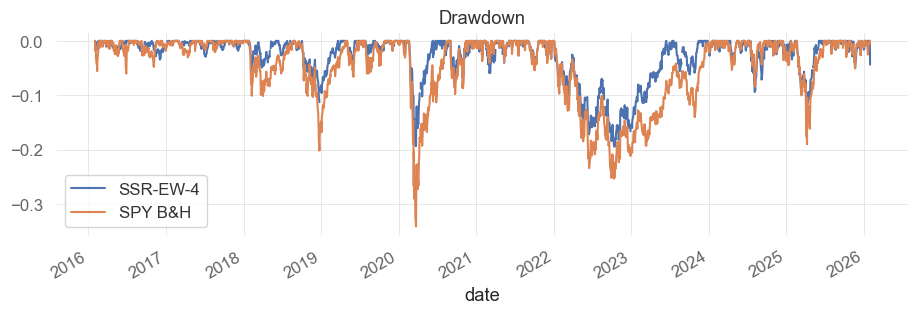

In [7]:
drawdowns = pd.DataFrame({
    "SSR-EW-4": pf.drawdown(),
    f"{BENCHMARK} B&H": bench.drawdown(),
})
drawdowns.plot(figsize=(11, 3), title="Drawdown", grid=True);

## 5. Full vectorbt stats table

In [8]:
pf.stats()

Start                         2016-02-01 00:00:00
End                           2026-01-30 00:00:00
Period                         2468 days 00:00:00
Start Value                              100000.0
End Value                           393707.046853
Total Return [%]                       293.707047
Benchmark Return [%]                   293.707047
Max Gross Exposure [%]                      100.0
Total Fees Paid                               0.0
Max Drawdown [%]                        19.482694
Max Drawdown Duration           354 days 00:00:00
Total Trades                                    4
Total Closed Trades                             0
Total Open Trades                               4
Open Trade PnL                      293707.046853
Win Rate [%]                                  NaN
Best Trade [%]                                NaN
Worst Trade [%]                               NaN
Avg Winning Trade [%]                         NaN
Avg Losing Trade [%]                          NaN
